# Exp 10: does the uncapped NPM improvement generalize to synthetic instances?

exp_10 generates synthetic instances with the instance generator (12 intermediaries, 10 sampled days per job, 196 jobs = 1,960 instances) and solves each with four strategies: `exact` (ground truth), `heuristic_accelerated`, `network_prioritized_capped` (index `σ_t / min(K, n_t + ε_t)`), and `network_prioritized_uncapped` (index `σ_t / (n_t + ε_t)`). Status-quo quantities use `hist_set_method="instance_farmers"`; epsilon and het-cost sampling match exp_8, so headline numbers are comparable to the exp_8/exp_9 analysis.

## Summary of findings

- **The uncapped improvement generalizes.** On hard instances (358 of 1,960, 18.3%), NPM's failure rate drops from 23.5% (capped) to 6.4% (uncapped), and gaps above 10% from 7.8% to 1.4% -- closely mirroring the real instances (27.7% → 8.1%, 11.0% → 2.1%).
- **Paired: 61 fixed, 2 improved, 0 broken, 0 worsened, 21 unchanged.** No regressions on synthetic instances (vs. one, `job_114/run_7`, on real ones), so "best of both" is identical to uncapped here.
- **All 21 unchanged failures pick identical sets under both indices** -- 12 have identical orderings, so they're unchanged by construction; the other 9 differ in ordering yet land on the same wrong set.
- **Why failures remain:** in all 23 remaining uncapped failures, some intermediary the optimum doesn't use is ranked ahead of one it needs. NPM only forces prefixes of one ordering, so the needed intermediary is reachable only by also forcing the unneeded one -- and the cost-minimizing oracle never adds it on its own, since its value is stability, not cost. A different ordering could reach the optimum in these cases; no simple signal identifies it (the stuck intermediary has a larger status-quo quantity than the blocker in only 11 of 23). See "Anatomy of the remaining failures" below.
- **Sanity check passes:** on all 1,199 instances where the two indices order intermediaries identically, capped and uncapped return identical results.
- **The heuristic never fails** (0 of 1,960), as on real instances, at a mean of 21s vs. 16s for either NPM variant and 40s for exact (exact's max is ~24 min; the heuristic's is 2 min).

In [1]:
from pathlib import Path
import gzip
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

In [2]:
sns.set_theme(context="paper", style="ticks")
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

palette = sns.color_palette()
STRATEGY_COLORS = {
    "Heuristic": palette[4],
    "NPM capped": palette[1],
    "NPM uncapped": palette[2],
    "NPM best of both": palette[3],
    "Exact": palette[0],
}
APPROX = ["Heuristic", "NPM capped", "NPM uncapped"]
ZERO_TOL = 1e-9          # relative gaps below this are floating-point noise
NONTRIVIAL_TOL = 1.0     # currency units; matches BRANCH_PRUNE_TOL in the solver
FIG_DIR = Path("../figures/exp_10")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load

In [3]:
runs = []
for file in sorted(Path("../results/exp_10").rglob("*.json.gz")):
    with gzip.open(file, "rt", encoding="utf-8") as f:
        payload = json.load(f)
    for run in payload["runs"]:
        runs.append((payload["experiment_metadata"]["job_id"], run))

print(f"loaded {len(runs)} runs from {len({job for job, _ in runs})} jobs")

loaded 1960 runs from 196 jobs


### Per-run table

Also records whether the capped and uncapped indices rank intermediaries differently on each instance. Where they don't, the two NPM variants run the identical search and must return identical results -- checked below.

In [4]:
SUMMARY_KEYS = {
    "exact": "summary_exact",
    "heuristic": "summary_heuristic",
    "capped": "summary_npm_capped",
    "uncapped": "summary_npm_uncapped",
}

def primary(summary):
    return summary["platform_solve_result"]["primary_result"]

def rel_gap(exact, profit):
    # platform profit can be negative, so normalize by |exact| to keep the sign meaningful
    return (exact - profit) / abs(exact) if exact != 0 else np.nan

def npm_ordering(summary, capped: bool):
    params = summary["params"]
    K = summary["instance_snapshot"]["constants"]["truck_capacity_tons"]
    n = Counter()
    for farmer in summary["instance_snapshot"]["farmers"]:
        n[farmer["intermediary_id"]] += farmer["quantity"]
    eps, sigma = params["epsilons"], params["het_costs"]
    def score(i):
        denom = max(n[i] + eps[i], 1e-4)
        return sigma[i] / (min(K, denom) if capped else denom)
    return sorted(sigma, key=lambda i: (score(i), -eps[i]))

rows = []
for job_id, run in runs:
    summaries = {name: run[key] for name, key in SUMMARY_KEYS.items()}
    results = {name: primary(s) for name, s in summaries.items()}
    exact_profit = results["exact"]["platform_profit"]
    exact_selected = set(results["exact"]["selected_intermediaries"])
    row = {
        "job_id": job_id,
        "sample_index": run["metadata"]["sample_index"],
        "n_farmers": run["metadata"]["n_farmers"],
        "exact_profit": exact_profit,
        # true optimum strictly beats the efficient (min-cost) matching: the only
        # instances where NPM can have a nonzero gap at all
        "is_hard": exact_profit - summaries["exact"]["forced_lower_bound"] > NONTRIVIAL_TOL,
        "ordering_differs": npm_ordering(summaries["exact"], True) != npm_ordering(summaries["exact"], False),
    }
    for name in SUMMARY_KEYS:
        row[f"{name}_profit"] = results[name]["platform_profit"]
        row[f"{name}_time"] = summaries[name]["total_time"]
        row[f"{name}_oracle_calls"] = summaries[name]["total_oracle_calls"]
        if name != "exact":
            row[f"{name}_gap"] = rel_gap(exact_profit, results[name]["platform_profit"])
            row[f"{name}_matches_exact"] = set(results[name]["selected_intermediaries"]) == exact_selected
    row["capped_selected"] = frozenset(results["capped"]["selected_intermediaries"])
    row["uncapped_selected"] = frozenset(results["uncapped"]["selected_intermediaries"])
    rows.append(row)

df = pd.DataFrame(rows)
df.shape

(1960, 25)

In [5]:
print("Negative gaps (strategy beats exact):")
print(df.query("heuristic_gap < -1e-6 or capped_gap < -1e-6 or uncapped_gap < -1e-6")[
    ["job_id", "sample_index", "heuristic_gap", "capped_gap", "uncapped_gap"]
])

for col in ["heuristic_gap", "capped_gap", "uncapped_gap"]:
    df[col] = df[col].clip(lower=0)

# running both NPM orderings and keeping the more profitable result
df["best_gap"] = df[["capped_gap", "uncapped_gap"]].min(axis=1)

same_order = df.query("not ordering_differs")
mismatch = same_order.query("capped_selected != uncapped_selected or abs(capped_profit - uncapped_profit) > 1e-3")
print(f"\nidentical orderings: {len(same_order)} runs; capped/uncapped results differ on {len(mismatch)} of them")
print(f"orderings differ on {df['ordering_differs'].sum()} / {len(df)} runs ({df['ordering_differs'].mean():.1%})")

Negative gaps (strategy beats exact):
Empty DataFrame
Columns: [job_id, sample_index, heuristic_gap, capped_gap, uncapped_gap]
Index: []

identical orderings: 1199 runs; capped/uncapped results differ on 0 of them
orderings differ on 761 / 1960 runs (38.8%)


In [6]:
GAP_COLS = {
    "Heuristic": "heuristic_gap",
    "NPM capped": "capped_gap",
    "NPM uncapped": "uncapped_gap",
    "NPM best of both": "best_gap",
}
long_df = pd.concat(
    [df.assign(strategy=name, gap=df[col]) for name, col in GAP_COLS.items()],
    ignore_index=True,
)

## Headline: failure rates

As in the exp_8/exp_9 analysis, a nonzero NPM gap is only possible on "hard" instances (true optimum beats the efficient matching), so the hard-only rows are the meaningful ones for NPM. The heuristic has no such guarantee.

In [7]:
THRESHOLDS = [ZERO_TOL, 1e-3, 1e-2, 0.05, 0.10]

def threshold_row(gaps):
    return {f"gap > {t:.1%}": (gaps > t).mean() for t in THRESHOLDS} | {"n": len(gaps)}

hard = df.query("is_hard")
print(f"hard instances: {len(hard)} of {len(df)} ({len(hard) / len(df):.1%})")

threshold_table = pd.DataFrame(
    {f"{name} (all)": threshold_row(df[col]) for name, col in GAP_COLS.items()}
    | {f"{name} (hard)": threshold_row(hard[col]) for name, col in GAP_COLS.items()}
).T
threshold_table["n"] = threshold_table["n"].astype(int)
threshold_table

hard instances: 358 of 1960 (18.3%)


,gap > 0.0%,gap > 0.1%,gap > 1.0%,gap > 5.0%,gap > 10.0%,n
Heuristic (all),0.000000,0.000000,0.000000,0.000000,0.000000,1960
NPM capped (all),0.042857,0.042347,0.037755,0.025510,0.014286,1960
NPM uncapped (all),0.011735,0.011735,0.009184,0.006122,0.002551,1960
NPM best of both (all),0.011735,0.011735,0.009184,0.006122,0.002551,1960
Heuristic (hard),0.000000,0.000000,0.000000,0.000000,0.000000,358
NPM capped (hard),0.234637,0.231844,0.206704,0.139665,0.078212,358
NPM uncapped (hard),0.064246,0.064246,0.050279,0.033520,0.013966,358
NPM best of both (hard),0.064246,0.064246,0.050279,0.033520,0.013966,358


### Comparison with the real-instance experiments (exp_8 / exp_9)

Hard-instance failure rates side by side. exp_8/9 numbers are recomputed from their saved results (exp_9's uncapped NPM joined to exp_8's exact solutions, as in `exp_9_results.ipynb`).

In [8]:
def load_runs(experiment):
    out = {}
    for file in Path(f"../results/{experiment}").rglob("*.json.gz"):
        with gzip.open(file, "rt", encoding="utf-8") as f:
            payload = json.load(f)
        for run in payload["runs"]:
            out[(payload["experiment_metadata"]["job_id"], run["metadata"]["run_index"])] = run
    return out

exp8, exp9 = load_runs("exp_8"), load_runs("exp_9")
real = []
for key in sorted(set(exp8) & set(exp9)):
    exact = primary(exp8[key]["summary_exact"])["platform_profit"]
    real.append({
        "is_hard": exact - exp8[key]["summary_exact"]["forced_lower_bound"] > NONTRIVIAL_TOL,
        "heuristic_gap": max(0, rel_gap(exact, primary(exp8[key]["summary_heuristic"])["platform_profit"])),
        "capped_gap": max(0, rel_gap(exact, primary(exp8[key]["summary_npm"])["platform_profit"])),
        "uncapped_gap": max(0, rel_gap(exact, primary(exp9[key]["summary_npm"])["platform_profit"])),
    })
real_df = pd.DataFrame(real)
real_df["best_gap"] = real_df[["capped_gap", "uncapped_gap"]].min(axis=1)

def failure_summary(frame):
    h = frame.query("is_hard")
    return {
        "hard instances": f"{len(h)} / {len(frame)} ({len(h) / len(frame):.1%})",
        **{f"{name}: P(gap > 0 | hard)": f"{(h[col] > ZERO_TOL).mean():.1%}" for name, col in GAP_COLS.items()},
        **{f"{name}: P(gap > 10% | hard)": f"{(h[col] > 0.10).mean():.1%}" for name, col in GAP_COLS.items()},
    }

pd.DataFrame({
    "real (exp_8/9)": failure_summary(real_df),
    "synthetic (exp_10)": failure_summary(df),
})

,real (exp_8/9),synthetic (exp_10)
hard instances,383 / 1959 (19.6%),358 / 1960 (18.3%)
Heuristic: P(gap > 0 | hard),0.0%,0.0%
NPM capped: P(gap > 0 | hard),27.7%,23.5%
NPM uncapped: P(gap > 0 | hard),8.1%,6.4%
NPM best of both: P(gap > 0 | hard),7.8%,6.4%
Heuristic: P(gap > 10% | hard),0.0%,0.0%
NPM capped: P(gap > 10% | hard),11.0%,7.8%
NPM uncapped: P(gap > 10% | hard),2.1%,1.4%
NPM best of both: P(gap > 10% | hard),2.1%,1.4%


## Paired comparison: capped vs. uncapped

Run by run: which failures does uncapping fix, and does it break anything? Split by whether the two indices order intermediaries differently -- where they don't, the outcome is "same" by construction.

In [9]:
def outcome(row):
    c, u = row["capped_gap"] > ZERO_TOL, row["uncapped_gap"] > ZERO_TOL
    if not c and not u:
        return "both exact"
    if c and not u:
        return "fixed by uncapping"
    if not c and u:
        return "broken by uncapping"
    if row["uncapped_gap"] < row["capped_gap"] - ZERO_TOL:
        return "both fail, uncapped better"
    if row["uncapped_gap"] > row["capped_gap"] + ZERO_TOL:
        return "both fail, uncapped worse"
    return "both fail, same gap"

df["outcome"] = df.apply(outcome, axis=1)
outcome_order = [
    "both exact", "fixed by uncapping", "broken by uncapping",
    "both fail, uncapped better", "both fail, uncapped worse", "both fail, same gap",
]
outcome_table = (
    df.assign(group=np.where(~df["is_hard"], "easy",
                             np.where(df["ordering_differs"], "hard, orderings differ", "hard, same ordering")))
    .groupby("group")["outcome"].value_counts()
    .unstack(fill_value=0)
    .reindex(columns=outcome_order, fill_value=0)
)
outcome_table.loc["total"] = outcome_table.sum()
outcome_table

outcome,both exact,fixed by uncapping,broken by uncapping,"both fail, uncapped better","both fail, uncapped worse","both fail, same gap"
group,,,,,,
easy,1602,0,0,0,0,0
"hard, orderings differ",122,61,0,2,0,9
"hard, same ordering",152,0,0,0,0,12
total,1876,61,0,2,0,21


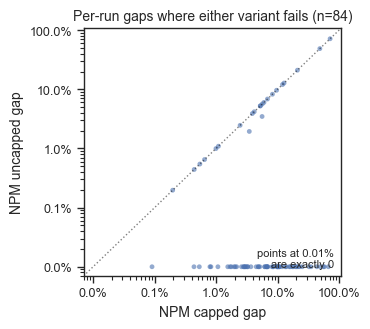

In [10]:
fig, ax = plt.subplots(figsize=(3.8, 3.4))

failed = df.query("capped_gap > @ZERO_TOL or uncapped_gap > @ZERO_TOL")
floor = 1e-4  # exact zeros drawn at a floor so they're visible on log axes
x = failed["capped_gap"].clip(lower=floor)
y = failed["uncapped_gap"].clip(lower=floor)
ax.scatter(x, y, s=12, alpha=0.6, color=palette[0], edgecolor="none")

lims = [floor * 0.7, max(x.max(), y.max()) * 1.5]
ax.plot(lims, lims, color="black", linestyle="dotted", linewidth=1, alpha=0.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
ax.set_xlabel("NPM capped gap")
ax.set_ylabel("NPM uncapped gap")
ax.set_title(f"Per-run gaps where either variant fails (n={len(failed)})")
ax.text(lims[1] / 1.3, lims[0] * 1.3, f"points at {floor:.2%}\nare exactly 0",
        fontsize=8, ha="right", va="bottom")

plt.tight_layout()
plt.savefig(FIG_DIR / "paired_gap_scatter.png", bbox_inches="tight", dpi=300)
plt.show()

## Gap distributions (nonzero gaps only)

Dominated by exact zeros, so restricted to nonzero gaps on a log axis.

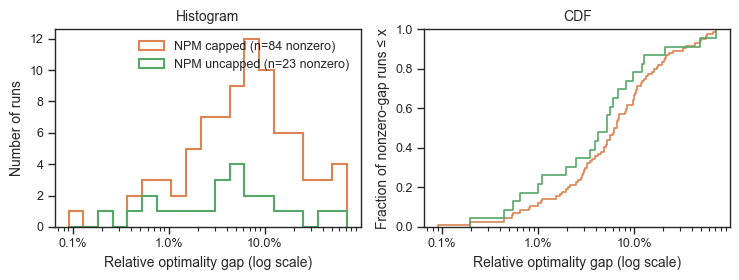

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(7.5, 2.9))

nonzero = long_df.query("gap > @ZERO_TOL and strategy in @APPROX")
bins = np.logspace(np.log10(nonzero["gap"].min()), np.log10(nonzero["gap"].max()), 20)

for name in APPROX:
    nz = nonzero.query("strategy == @name")
    if nz.empty:
        continue
    label = f"{name} (n={len(nz)} nonzero)"
    axes[0].hist(nz["gap"], bins=bins, histtype="step", linewidth=1.5,
                 color=STRATEGY_COLORS[name], label=label)
    axes[1].ecdf(nz["gap"], color=STRATEGY_COLORS[name], label=label)

for ax in axes:
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
    ax.set_xlabel("Relative optimality gap (log scale)")
axes[0].set_ylabel("Number of runs")
axes[0].set_title("Histogram")
axes[1].set_ylabel("Fraction of nonzero-gap runs \u2264 x")
axes[1].set_title("CDF")
axes[0].legend(frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "gap_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

## By instance size

In [12]:
SIZE_BINS = [0, 10, 15, 20, 25, np.inf]
SIZE_LABELS = ["\u226410", "11\u201315", "16\u201320", "21\u201325", ">25"]
df["size_bin"] = pd.cut(df["n_farmers"], SIZE_BINS, labels=SIZE_LABELS)
long_df["size_bin"] = pd.cut(long_df["n_farmers"], SIZE_BINS, labels=SIZE_LABELS)

size_rates = (
    long_df.query("is_hard")
    .assign(failed=lambda d: d["gap"] > ZERO_TOL)
    .groupby(["size_bin", "strategy"], observed=True)["failed"].mean()
    .unstack("strategy")[list(GAP_COLS)]
)
size_rates["n hard"] = df.query("is_hard").groupby("size_bin", observed=True).size()
size_rates

strategy,Heuristic,NPM capped,NPM uncapped,NPM best of both,n hard
size_bin,,,,,
≤10,0.0,0.071429,0.000000,0.000000,14
11–15,0.0,0.220000,0.040000,0.040000,100
16–20,0.0,0.223022,0.079137,0.079137,139
21–25,0.0,0.296296,0.086420,0.086420,81
>25,0.0,0.250000,0.041667,0.041667,24


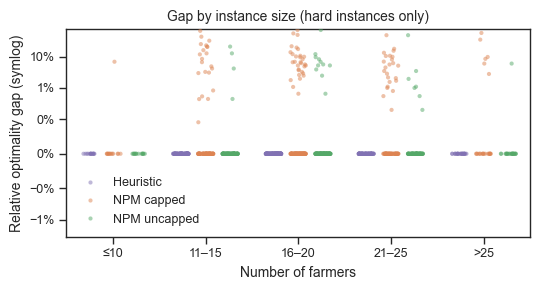

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 3))
sns.stripplot(
    data=long_df.query("is_hard and strategy in @APPROX"),
    x="size_bin", y="gap",
    hue="strategy", hue_order=APPROX, palette=STRATEGY_COLORS,
    dodge=True, alpha=0.5, size=3, jitter=0.25, ax=ax,
)
ax.set_yscale("symlog", linthresh=1e-3)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xlabel("Number of farmers")
ax.set_ylabel("Relative optimality gap (symlog)")
ax.set_title("Gap by instance size (hard instances only)")
ax.legend(title=None, frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "gap_by_size.png", bbox_inches="tight", dpi=300)
plt.show()

## Runtime

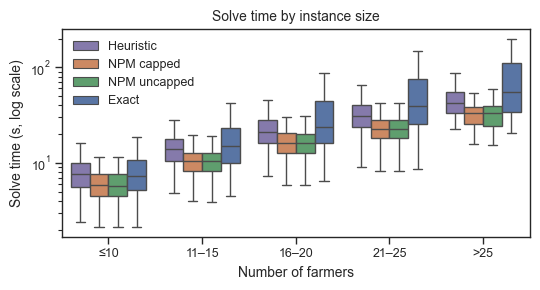

In [14]:
TIME_COLS = {"Heuristic": "heuristic_time", "NPM capped": "capped_time",
             "NPM uncapped": "uncapped_time", "Exact": "exact_time"}
time_long = pd.concat(
    [df[["size_bin"]].assign(strategy=name, time=df[col]) for name, col in TIME_COLS.items()],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(5.5, 3))
sns.boxplot(
    data=time_long, x="size_bin", y="time",
    hue="strategy", hue_order=list(TIME_COLS), palette=STRATEGY_COLORS,
    showfliers=False, ax=ax,
)
ax.set_yscale("log")
ax.set_xlabel("Number of farmers")
ax.set_ylabel("Solve time (s, log scale)")
ax.set_title("Solve time by instance size")
ax.legend(title=None, frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "solve_time_by_size.png", bbox_inches="tight", dpi=300)
plt.show()

In [15]:
df[[col for col in TIME_COLS.values()] + ["capped_oracle_calls", "uncapped_oracle_calls"]].describe().loc[["mean", "50%", "max"]]

,heuristic_time,capped_time,uncapped_time,exact_time,capped_oracle_calls,uncapped_oracle_calls
mean,21.425082,15.647940,15.642652,40.279037,4.639286,4.483163
50%,18.251899,13.792937,13.806566,20.486370,5.000000,4.000000
max,120.525212,73.798580,73.729424,1415.286405,10.000000,9.000000


## Remaining failures and regressions

Candidates for the same kind of case-by-case diagnosis done in exp_8/exp_9.

In [16]:
cols = ["job_id", "sample_index", "n_farmers", "ordering_differs", "heuristic_gap", "capped_gap", "uncapped_gap", "outcome"]
print("Worst uncapped failures:")
display(df.query("uncapped_gap > @ZERO_TOL").sort_values("uncapped_gap", ascending=False)[cols].head(10))

print("Runs made worse by uncapping:")
display(
    df.query("outcome in ['broken by uncapping', 'both fail, uncapped worse']")
    .sort_values("uncapped_gap", ascending=False)[cols]
)

print("Heuristic failures:")
display(df.query("heuristic_gap > @ZERO_TOL").sort_values("heuristic_gap", ascending=False)[cols].head(10))

Worst uncapped failures:


,job_id,sample_index,n_farmers,ordering_differs,heuristic_gap,capped_gap,uncapped_gap,outcome
865,176,5,18,False,0.000000e+00,0.715935,0.715935,"both fail, same gap"
1817,86,7,22,False,3.224768e-13,0.487678,0.487678,"both fail, same gap"
1733,79,3,14,True,0.000000e+00,0.210575,0.210575,"both fail, same gap"
809,170,9,15,True,0.000000e+00,0.127616,0.127616,"both fail, same gap"
1001,189,1,16,False,0.000000e+00,0.120408,0.120408,"both fail, same gap"
874,177,4,16,True,0.000000e+00,0.096396,0.096396,"both fail, same gap"
833,173,3,19,False,0.000000e+00,0.082577,0.082577,"both fail, same gap"
1710,77,0,19,True,7.579623e-15,0.068491,0.068491,"both fail, same gap"
1816,86,6,28,True,0.000000e+00,0.060124,0.060124,"both fail, same gap"
517,144,7,20,True,0.000000e+00,0.056423,0.056423,"both fail, same gap"


Runs made worse by uncapping:


,job_id,sample_index,n_farmers,ordering_differs,heuristic_gap,capped_gap,uncapped_gap,outcome


Heuristic failures:


,job_id,sample_index,n_farmers,ordering_differs,heuristic_gap,capped_gap,uncapped_gap,outcome


### Do the unchanged failures pick the same set under both indices?

Checks whether, when both variants fail with the same gap, they fail by choosing the same intermediaries.

In [17]:
same_gap = df.query("outcome == 'both fail, same gap'")
print(f"'both fail, same gap': {len(same_gap)} runs; identical capped/uncapped selection in "
      f"{(same_gap['capped_selected'] == same_gap['uncapped_selected']).sum()}; "
      f"orderings differ in {same_gap['ordering_differs'].sum()}")

'both fail, same gap': 21 runs; identical capped/uncapped selection in 21; orderings differ in 9


## Anatomy of the remaining failures

Tracing `job_176/sample_5` (71.6% gap) through NPM's log: the optimum is `{nervous_cori, dazzling_booth, sweet_lumiere, focused_hoover}`. NPM's uncapped order ranks `stupefied_brown` 3rd -- not in the optimum -- ahead of `focused_hoover` (5th), which the optimum needs for stability (a full truck of status-quo farmers, `n = 9.0`). For `k = 0..4` the min-cost oracle returns the efficient set every time (containing the cheap `stupefied_brown`, never the expensive `focused_hoover`); at `k = 5`, forcing `focused_hoover` also forces `stupefied_brown`, needing a 5th truck, and the bound prunes. Had `focused_hoover` been ranked ahead of `stupefied_brown`, the prefix `{nervous_cori, dazzling_booth, focused_hoover}` plus the oracle's cheapest fourth pick would be exactly the optimum.

The general version: for each uncapped failure, find the first intermediary in NPM's ordering that the optimum doesn't use (the *blocker*), and the optimum's members ranked behind it (*stuck* -- only reachable by also forcing the blocker).

In [18]:
def uncapped_order_and_n(summary):
    params = summary["params"]
    n = Counter()
    for farmer in summary["instance_snapshot"]["farmers"]:
        n[farmer["intermediary_id"]] += farmer["quantity"]
    eps, sigma = params["epsilons"], params["het_costs"]
    order = sorted(sigma, key=lambda i: (sigma[i] / max(n[i] + eps[i], 1e-4), -eps[i]))
    return order, n

run_lookup = {(job_id, run["metadata"]["sample_index"]): run for job_id, run in runs}
anatomy = []
for row in df.query("uncapped_gap > @ZERO_TOL").itertuples():
    run = run_lookup[(row.job_id, row.sample_index)]
    optimum = set(primary(run["summary_exact"])["selected_intermediaries"])
    npm_pick = set(row.uncapped_selected)
    order, n = uncapped_order_and_n(run["summary_exact"])
    rank = {iid: r for r, iid in enumerate(order, 1)}
    blocker_rank = next(r for r, iid in enumerate(order, 1) if iid not in optimum)
    blocker = order[blocker_rank - 1]
    stuck = sorted((iid for iid in optimum if rank[iid] > blocker_rank), key=rank.get)
    anatomy.append({
        "job_id": row.job_id,
        "sample_index": row.sample_index,
        "gap": row.uncapped_gap,
        "blocker (rank)": f"{blocker} ({blocker_rank})",
        "blocker in NPM pick": blocker in npm_pick,
        "blocker n": n[blocker],
        "stuck (rank)": ", ".join(f"{iid} ({rank[iid]})" for iid in stuck),
        "stuck missing from NPM pick": any(iid not in npm_pick for iid in stuck),
        "max stuck n": max((n[iid] for iid in stuck), default=np.nan),
    })

anatomy = pd.DataFrame(anatomy).sort_values("gap", ascending=False)
print(f"uncapped failures: {len(anatomy)}")
print(f"  optimum member ranked behind a non-member: {(anatomy['stuck (rank)'] != '').sum()}")
print(f"  ...with a stuck member missing from NPM's pick: {anatomy['stuck missing from NPM pick'].sum()}")
print(f"  blocker is itself in NPM's pick (takes the slot): {anatomy['blocker in NPM pick'].sum()}")
print(f"  blocker not in NPM's pick (forcing it gets pruned): {(~anatomy['blocker in NPM pick']).sum()}")
print(f"    ...of which the stuck member has zero status quo: {((~anatomy['blocker in NPM pick']) & (anatomy['max stuck n'] == 0)).sum()}")
print(f"  stuck member has larger status quo than blocker: {(anatomy['max stuck n'] > anatomy['blocker n']).sum()}")
anatomy

uncapped failures: 23
  optimum member ranked behind a non-member: 23
  ...with a stuck member missing from NPM's pick: 23
  blocker is itself in NPM's pick (takes the slot): 16
  blocker not in NPM's pick (forcing it gets pruned): 7
    ...of which the stuck member has zero status quo: 5
  stuck member has larger status quo than blocker: 11


,job_id,sample_index,gap,blocker (rank),blocker in NPM pick,blocker n,stuck (rank),stuck missing from NPM pick,max stuck n
7,176,5,0.715935,stupefied_brown (3),True,4.8,"sweet_lumiere (4), focused_hoover (5)",True,9.0
21,86,7,0.487678,bold_elbakyan (2),True,4.7,"compassionate_blackwell (3), youthful_ramanuja...",True,6.5
19,79,3,0.210575,serene_roentgen (3),True,3.0,"strange_morse (4), magical_franklin (5)",True,1.2
4,170,9,0.127616,intelligent_sinoussi (1),True,2.2,"silly_babbage (2), gallant_northcutt (5), flam...",True,4.3
12,189,1,0.120408,trusting_moore (3),True,8.8,"keen_thompson (4), cranky_einstein (5)",True,6.4
9,177,4,0.096396,zealous_black (1),True,0.0,"brave_buck (2), elegant_archimedes (3), loving...",True,6.4
5,173,3,0.082577,modest_liskov (1),True,6.7,"eloquent_mendel (2), jolly_engelbart (3), stup...",True,1.9
18,77,0,0.068491,great_lederberg (3),True,9.0,"trusting_brown (4), stoic_mccarthy (5), epic_s...",True,6.7
20,86,6,0.060124,compassionate_blackwell (4),True,4.0,"great_swanson (5), angry_lichterman (6)",True,8.9
0,144,7,0.056423,goofy_wozniak (3),True,4.6,"gracious_cerf (4), agitated_rubin (5), goofy_b...",True,7.8


Every remaining failure has this shape, in two flavors: usually the blocker is cheap, so the oracle includes it for free and it takes the slot the needed intermediary should have had; otherwise forcing the blocker is itself costly, so the bound prunes there and nothing behind it is examined (mostly zero-status-quo intermediaries, whose `σ/ε` score ranks them low -- the zero-history mechanism from exp_8). Status quo alone doesn't identify the needed intermediary: it exceeds the blocker's in only about half the cases. Fixing this within NPM would need either a different ordering signal or evaluating more than one ordering / allowing substitutions in the candidate family.